
# Comparison of Regression Models

This notebook compares the performance **five regression models**:

## Models Compared
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Decision Tree Regressor
5. Gradient Boosting Regressor

## Evaluation Metrics
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Dataset used: **Breast Cancer Wisconsin Dataset** (from scikit-learn)

In [1]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor


In [2]:

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target.astype(float)  # Treat target as continuous

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [3]:

# Initialize regression models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}


In [4]:

# Train models and evaluate
results = {}

for name, model in models.items():
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = (mse, rmse, r2)
    print(f"{name} -> MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")


Linear Regression -> MSE: 0.0641, RMSE: 0.2532, R2: 0.7271
Ridge Regression -> MSE: 0.0621, RMSE: 0.2491, R2: 0.7359
Lasso Regression -> MSE: 0.0619, RMSE: 0.2489, R2: 0.7364
Decision Tree Regressor -> MSE: 0.0526, RMSE: 0.2294, R2: 0.7760
Gradient Boosting Regressor -> MSE: 0.0313, RMSE: 0.1768, R2: 0.8669


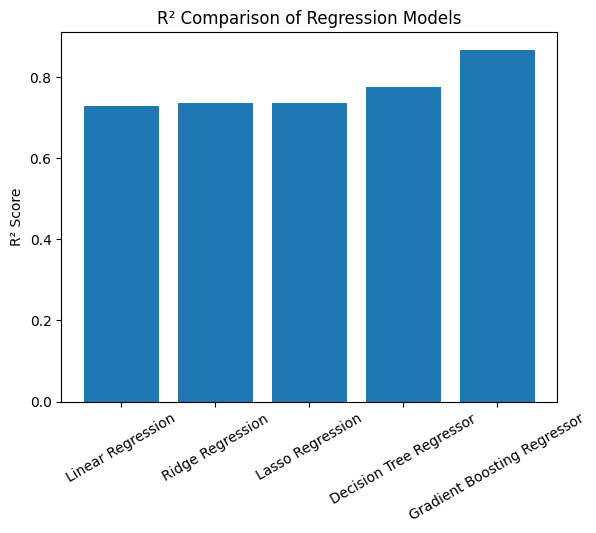

In [5]:

# R2 score comparison plot
model_names = list(results.keys())
r2_scores = [results[m][2] for m in model_names]

plt.figure()
plt.bar(model_names, r2_scores)
plt.ylabel("R² Score")
plt.title("R² Comparison of Regression Models")
plt.xticks(rotation=30)
plt.show()


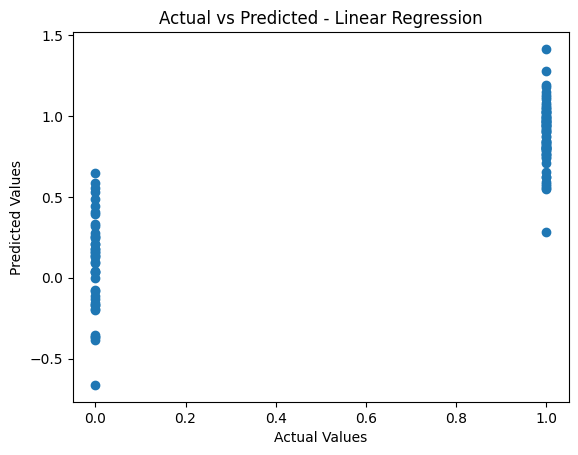

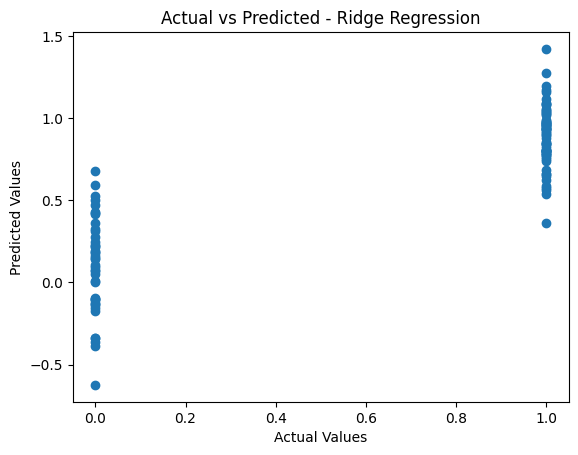

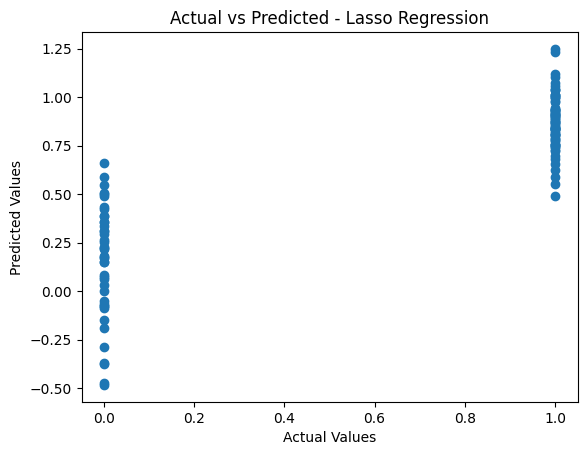

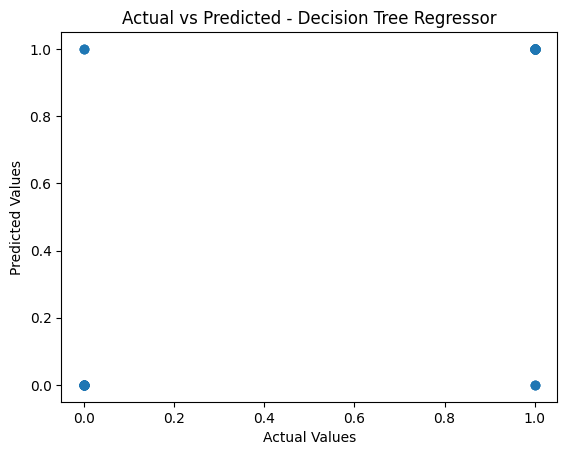

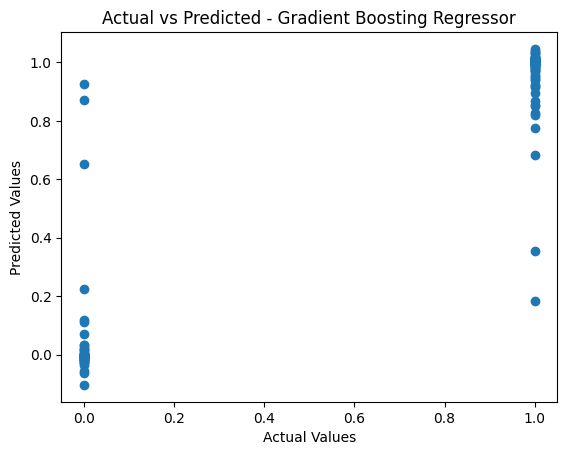

In [6]:

# Actual vs Predicted plots
for name, model in models.items():
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {name}")
    plt.show()



## Conclusion

- **Linear, Ridge, and Lasso Regression** perform similarly due to the linear separability of the dataset.
- **Ridge Regression** helps reduce coefficient magnitude and improves stability.
- **Lasso Regression** performs feature selection by shrinking some coefficients to zero.
- **Decision Tree Regressor** may overfit and show lower generalization.
- **Gradient Boosting Regressor** usually provides the best R² score due to ensemble learning.

This notebook demonstrates how regression models behave even on a dataset typically used for classification.
